<a href="https://colab.research.google.com/github/soonhyeong/NVIDIA_AI_Edu/blob/main/018_%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%EA%B8%B0%EC%B4%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 머신러닝 기초
* 데이터 정규화
* 선형 회귀(Linear Regression)
* 로지스틱 회귀(Logistic Regression)
* 아담 옵티마이저

# 1. 머신러닝 개념

## 1. 데이터를 기반으로 최적의 모델을 계산하여 완성
## 2. 이를 활용해 새로운 데이터를 예측하거나 분류할 수 있게 하는 방법

## 모델이란 ?
 >모델은 수식이 있다.
 >모델은 입력 데이터와 출력 데이터 관계를 수식으로 표현한 함수
* x : 입력값
* f : 모델
* y hat : 모델 예측 결괏값


* seaborn 에서 기본적으로 제공하는 "tips" 라는 데이터셋을 통해서 연습
* "tips" : 미국 레스토랑에서 사람들에게 받은 가격별 팁
* 선형 회귀 : "추세선"을 찾아내는 머신러닝 모델

#학습과 추론?
* 추세선을 만들어 내면 예측이 가능하다
* 모델을 만드는 과정을 "학습"
* 완성된 모델을 활용하여 예측하는 것을 "추론"


<Axes: xlabel='total_bill', ylabel='tip'>

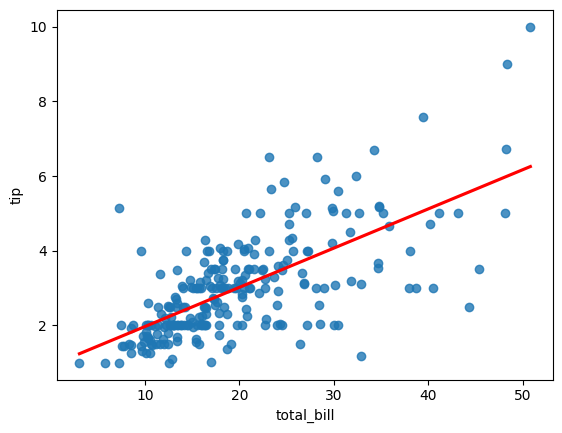

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

sns.regplot(x="total_bill", y="tip", data = tips, ci=None, line_kws={'color':'red'})

* 위 그래프를 보고 예측할 수 있는가?
* 예를 들면, 50달러치 식사를 하면 어느정도 Tip을 받을까요? 대략 $6

# 머신러닝 정의 다시 살펴보기
* 데이터를 기반으로 최적의 모델을 계산하여 완성
* 데이터를 예측하거나 분류

# LLM
* LLM에서 사용되는 신경망도 머신러닝의 일종

# 선형 회귀 모델에 대해 이해하기
* 선형 회귀 모델은 피쳐(feature)의 추세선이다.
 * 피쳐라고는 대상에서 값으로 표현하면서 모델에 입력되는 변수
 * 사람 대상으로 키, 몸무게 (feature)

<br/>
# 선형 회귀 모델을 만드는 방법
* 피쳐가 2개면 선이고, 2개면 면
* 피쳐가 1개일 때를 먼저 생각해 볼게요.
* 선 > 직선 > 직선의 방정식으로 이뤄져 있다.

* 목표는 "점들과 떨어져 있는 거리의 합이 최소"인 선을 찾아내는 것이다. a, b 값을 찾아내야 한다.
* 실제 y값과 예측된 y값과의 차이를 오차라고 부릅니다.
* 각 점별로 오차의 합이 최소가 되는 직선을 찾으면, 최고의 추세선입니다.

* a,b값은 2중 for문을 돌리면서 "오차의 합"이 최소가 되는 a,b값을 찾아냅니다.
* Grid Search

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


tips = sns.load_dataset("tips")

X = tips["total_bill"].values
y = tips["tip"].values

a_values = np.linspace(0, 2, 100)
b_values = np.linspace(0, 5, 100)

best_a, best_b = None, None
min_error = float("inf")

for a in a_values:
  for b in b_values:

    y_hat = a * X + b

    error = np.sum(np.abs(y - y_hat))

    if error < min_error:
      min_error = error
      best_a, best_b = a, b


print(best_a) # 최적의 기울기
print(best_b) # 최적의 절편
print(min_error) # 최소 오차의 합


0.12121212121212122
0.5555555555555556
179.96868686868686


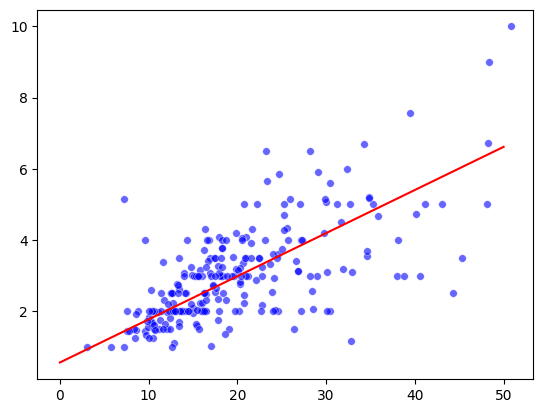

In [ ]:
sns.scatterplot(x = X , y =y, s = 30, color = "blue", alpha = 0.6)

x_line = np.linspace(0, 50, 100)
y_line = best_a * x_line + best_b
plt.plot(x_line, y_line, color="red")
plt.show()

# 오차의 단순 합이 가지는 문제점
## 1. 오차끼리 서로 상쇄되는 문제가 있다.
 * 데이터1 : 실제값100, 예측값 120 > 오차 -20
 * 데이터2 : 실제값100, 예측값 80 > 오차 +20
 * 오차의합 = 0

 ## 2. '합'이 아니라 '평균'을 내야하는 이유
 * A 시험지(문항수10개) : 문제당 평균 2점씩 틀림 > 오차의합이 20
 * B 시험지(문항수100개) : 문제당 평균 0.5점씩 틀림 > 오차의합이 50

 * 오차의 평균을 구한다.
 * A 시험지 평균 오차 : 20 나누기 10 = 2.0
 * B 시험지 평균 오차는 50 나누기 100 = 0.5
 * 오차 평균이 훨씬 적은 0.5가 더 우수하다.


# MAE(Mean Absolute Error)

* 위 내용은 오차의 합이 최소가 되는 것을 구했습니다.
* 오차의 합을 기준으로 하면 좋은 a, b를 구할 순 있습니다.
* 하지만, 오차의 합 값 자체는 의미가 없다.
*'오차의 평균'은 데이터가 많거나 적거나, 예측 모델과 실제 값들의 차이를 잘 설명할 수 있습니다.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


tips = sns.load_dataset("tips")

X = tips["total_bill"].values
y = tips["tip"].values

a_values = np.linspace(0, 2, 100)
b_values = np.linspace(0, 5, 100)

best_a, best_b = None, None
min_error = float("inf")

for a in a_values:
  for b in b_values:

    y_hat = a * X + b

    #error = 오차의 합
    #error = np.sum(np.abs(y - y_hat)) <---- 주석처리
    error = np.mean(np.abs(y - y_hat)) # 오차의 평균

    if error < min_error:
      min_error = error
      best_a, best_b = a, b


print(best_a) # 최적의 기울기
print(best_b) # 최적의 절편
print(min_error) # 최소 오차 평균


0.12121212121212122
0.5555555555555556
0.7375765855274051


* 결과는 크게 달라지지 않지만, 0.73 수치가 의미있다.

# MSE(Meas Sequre Error)
* MAE는 오차 값에 적절히 반영
* 오차가 크게 발생하면 아주 큰 에러라고 강조하고 싶을때
* 오차에 제곱을 하여 오차 값에 크게 반응

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

tips = sns.load_dataset("tips")

X = tips["total_bill"].values
y = tips["tip"].values

a_values = np.linspace(0, 2, 100)
b_values = np.linspace(0, 5, 100)

best_a, best_b = None, None
min_error = float("inf")

for a in a_values:
  for b in b_values:

    y_hat = a * X + b

    #error = 오차의 합
    #error = np.sum(np.abs(y - y_hat)) <---- 주석처리
    #error = np.mean(np.abs(y - y_hat)) <---- 주석처리 // 오차의 평균(MAE)
    error = np.mean(np.abs( y - y_hat) ** 2) # 오차 제곱의 평균(MSE)

    if error < min_error:
      min_error = error
      best_a, best_b = a, b


print(best_a) # 최적의 기울기
print(best_b) # 최적의 절편
print(min_error) # 최소 오차 제곱 평균


0.10101010101010102
1.0101010101010102
1.0373996209821346


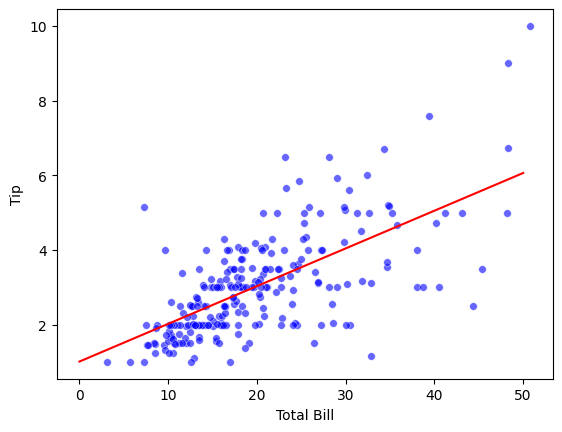

In [ ]:
sns.scatterplot(x = X , y =y, s = 30, color = "blue", alpha = 0.6)

x_line = np.linspace(0, 50, 100)
y_line = best_a * x_line + best_b

plt.plot(x_line, y_line, color="red")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

* 머신러닝에서 가장 많이 사용하는 MSE

# Gradient Descent(GD)
* 경사하강법 "함수의 기울기(경사)"를 구하고, 기울기가 낮은쪽으로 이동하여 함수의 최솟값을 찾는 알고리즘

* GD가 진행되는 과정을 반복하면 적은 횟수로 MSE가 좋은 a값을 찾을 수 있습니다.

Epoch0, MSE=476.0046, a=-0.4397, b=1.2390
Epoch100, MSE=1.0549, a=0.0909, b=1.2557
Epoch200, MSE=1.0543, a=0.0911, b=1.2501
Epoch300, MSE=1.0537, a=0.0914, b=1.2446
Epoch400, MSE=1.0531, a=0.0916, b=1.2392
Epoch500, MSE=1.0525, a=0.0918, b=1.2339
Epoch600, MSE=1.0520, a=0.0920, b=1.2287
Epoch700, MSE=1.0515, a=0.0923, b=1.2236
Epoch800, MSE=1.0510, a=0.0925, b=1.2186
Epoch900, MSE=1.0505, a=0.0927, b=1.2136


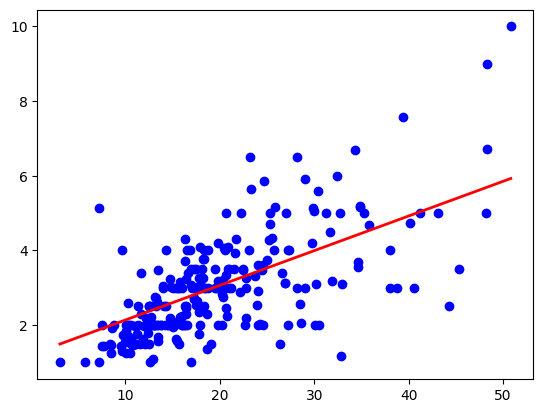

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

tips = sns.load_dataset("tips")

X = tips["total_bill"].values
y = tips["tip"].values

# 파라미터 초기화 ( a : 기울기, b : 절편)
a = np.random.randn()
b = np.random.randn()


# 하이퍼파라미터
lr = 0.001 # 학습률
epochs = 1000 # 몇 번 반복학습 할지?? ( 점프 횟수)

# Gradient Descent 학습
for epoch in range(epochs):
  y_hat = a * X + b # 모든 데이터 대한 예측

  error = y_hat - y # 오차

  # 기울기 계산
  grad_a = np.mean(error * X)
  grad_b = np.mean(error)

  a -= lr * grad_a
  b -= lr * grad_b

  # 학습 현황
  if epoch % 100 == 0:
    mse = np.mean((y-y_hat)**2)
    print(f"Epoch{epoch}, MSE={mse:.4f}, a={a:.4f}, b={b:.4f}")

plt.scatter(X, y, color='blue', label='Data')
x_line = np.linspace(X.min(), X.max(), 100)
y_line = a * x_line + b
plt.plot(x_line, y_line, color='red', linewidth= 2, label= 'GD Line')


# 선형회귀 정리
* 선형 회귀 모델은 '추세선'을 만드는 것이다.
* 수식이 만들어지면 새로운 값을 예측할 수 있고 이것을 머신러닝 이라고 합니다
- 선형 회귀 모델을 만드는 방법은 2개
 - MSE
   - y = ax + b의 a, b 값을 계산하여 MSE가 최소인 값을 구합니다.
   - 단점은 계산량이 많고 피쳐가 너무 많으면 계산이 어렵다.
 - Gradient Decent(경사 하강법)
   -  MSE가 최소인 곳을 향해 점프 점프 한다.
   - Local Minimum에 빠질 수 있어서, 아담 같은 경사하강법을 사용해야 한다.

로지스틱 회귀(Logistic Regression)
- 회귀(Resgression) 수를 예측한다는 뜻
- 실제로 분류를 하는 기법 중 하나입니다. 입력 값이 두 범주 중 한 범주에 속할 확률을 예측하는 기법입니다.

#이진분류 예시
- 2가지 중 1개를 선택하는 것을 저희는 '이진분류' 라고 합니다.
- 예를 들면
- 공부 시간을 넣으면 시험에 합격 또는 불합격
- 키워드를 넣고 스팸메일인지 아닌지
- 여러 건강정보를 넣고 질병에 걸릴 확률이 있는지 없는지

* 주어진 데이터가
 * 2시간 공부한 학생 A : 불합격
 * 3시간 공부한 학생 B : 불합격
 * 4시간 공부한 학생 C : 합격
 * 5시간 공부한 학생 D : 합격
 * 3시간 공부한 학생 E : 불합격

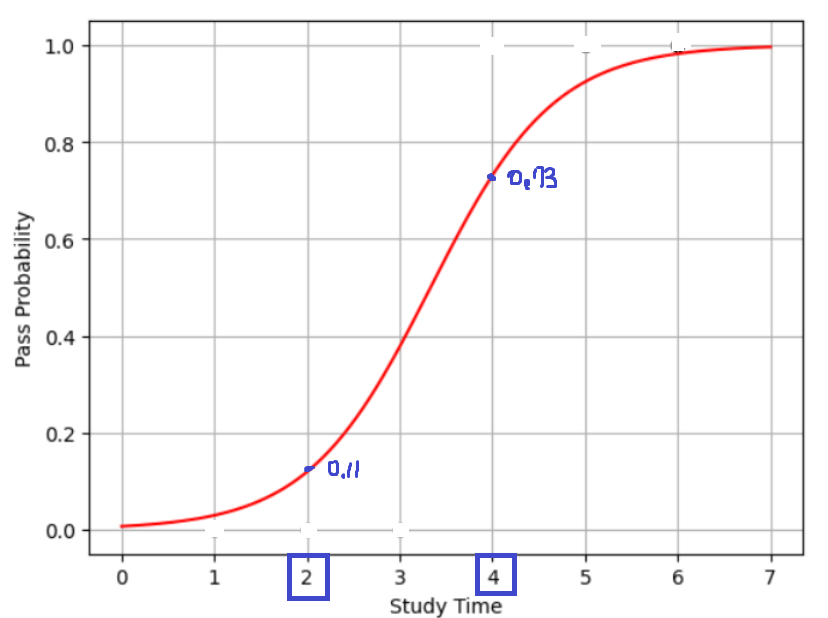

# 로지스틱 회귀는 수식이 있습니다.

* 시그모이드 함수

def sigmoid(z):
 return 1 / (1 + np.exp(-z))

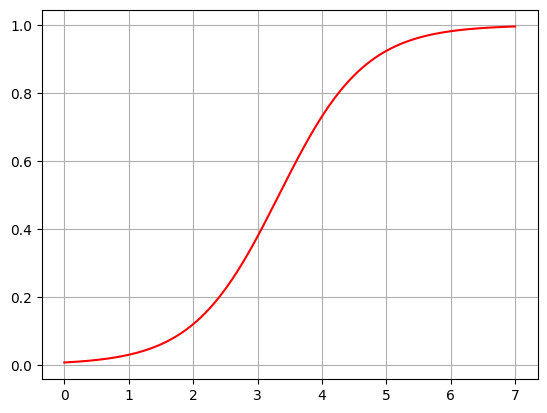

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

a = 1.5
b = -5

X = np.linspace(0, 7, 200)

y_hat = sigmoid(a * X + b)

plt.plot(X, y_hat, color='red')
plt.grid(True)
plt.show()

- 로지스틱은 y = sigmoid(ax + b)에서 a, b 를 알아낸 후 확률 곡선을 만들어 내야 하는문제입니다.

# 로지스틱 회귀 문제에 Grid Search 적용하기
 - 선형 회귀 문제처럼 2중 for문을 사용하여 최적의 a, b 값을 확인해보기
 - 최적의 값을 구현해보는 과정은 완벽한 이해를 위해 필요합니다.

2.8181818181818183
-10.0
0.11022994446293707


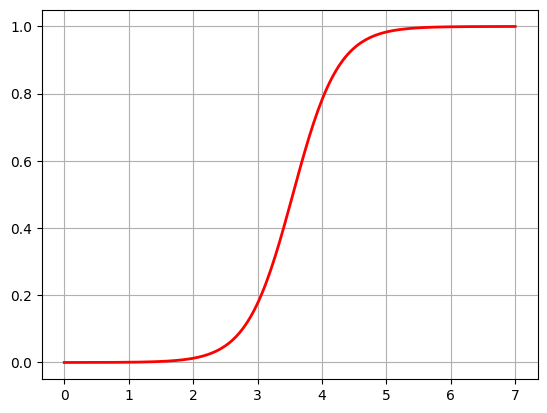

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def get_loss(y , y_hat):
  return np.sum((y - y_hat)**2) #MSE

X = np.array([1,5,2,6,7,3,1,2,3,4]) # 공부시간
y = np.array([0,1,0,1,1,0,0,0,0,1]) # 합격여부( 0 - 불합격, 1 - 합격)

a_values = np.linspace(0,3,100)
b_values = np.linspace(-10,10,100)

best_a, best_b = None, None
min_loss = float("inf")

#Grid Search
for a in a_values:
  for b in b_values:
    y_hat = sigmoid(a * X + b) # X의 모든 데이터로 예측값들 y_hat 만듥;

    loss = get_loss(y , y_hat)

    if loss < min_loss:
      min_loss = loss
      best_a, best_b = a, b

print(best_a)
print(best_b)
print(min_loss)

# 최적 파라미터 곡선
X_test = np.linspace(0, 7, 200)
y_prob = sigmoid(best_a * X_test + best_b)

plt.plot(X_test, y_prob, color='red', linewidth= 2)
plt.grid(True)
plt.show()

# 크로스 엔트로피
* Error 구하는 공식을 Loss Function 이라고 합니다.
* Loss Fiunction으로 MSE를 사용했고 MSE 값이 최소가 되는 a, b를 찾는게 목표

* MSE를 사용하는 이유는 오차의 제곱을 사용해서 오차를 크게 보기 위함
* 0.5를 제곱하며 0.5보다 더 작아져요.

* 따라서, 작은 오차는 적게, 큰 오차는 크게 확대를 해주는  Loss Function이 있다. 그게 '크로스 엔트로피'
* 로지스틱회귀와 같은 분류 문제는 Loss Function으로 '크로스 엔트로피' 가장 많이 사용

2.787878787878788
-10.0
0.06763270092558238


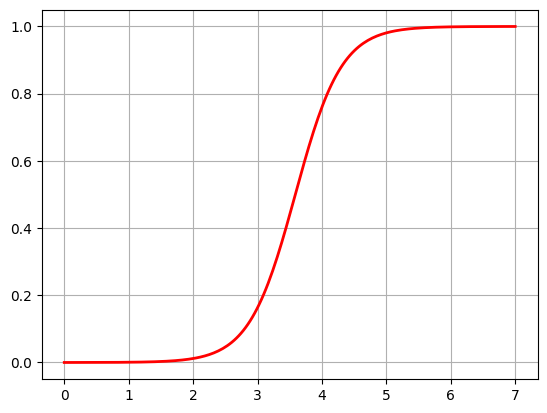

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def get_loss(y , y_hat):
  #return np.sum((y - y_hat)**2) # MSE는 주석처리

  #크로스 엔트로피
  eps = 1e-10
  return -np.mean(y*np.log(y_hat+eps) + (1-y)* np.log(1-y_hat+eps))

X = np.array([1,5,2,6,7,3,1,2,3,4]) # 공부시간
y = np.array([0,1,0,1,1,0,0,0,0,1]) # 합격여부( 0 - 불합격, 1 - 합격)

a_values = np.linspace(0,3,100)
b_values = np.linspace(-10,10,100)

best_a, best_b = None, None
min_loss = float("inf")

#Grid Search
for a in a_values:
  for b in b_values:
    y_hat = sigmoid(a * X + b) # X의 모든 데이터로 예측값들 y_hat 만듥;

    loss = get_loss(y , y_hat)

    if loss < min_loss:
      min_loss = loss
      best_a, best_b = a, b

print(best_a)
print(best_b)
print(min_loss)

# 최적 파라미터 곡선
X_test = np.linspace(0, 7, 200)
y_prob = sigmoid(best_a * X_test + best_b)

plt.plot(X_test, y_prob, color='red', linewidth= 2)
plt.grid(True)
plt.show()

* min_loss값이 더 낮아질수록 정답에 대한 확신이 생긴다.

#Grid Search 대신 GD로 좋은 파라미터를 찾아내기

Epoch 0, Loss=0.4927, a=0.4628, b=-0.1585
Epoch 500, Loss=0.1919, a=1.1326, b=-3.5483
Epoch 1000, Loss=0.1389, a=1.5473, b=-5.1052
Epoch 1500, Loss=0.1141, a=1.8402, b=-6.1758
Epoch 2000, Loss=0.0988, a=2.0728, b=-7.0162
Epoch 2500, Loss=0.0881, a=2.2689, b=-7.7197
Epoch 3000, Loss=0.0800, a=2.4402, b=-8.3314
Epoch 3500, Loss=0.0736, a=2.5933, b=-8.8763
Epoch 4000, Loss=0.0684, a=2.7323, b=-9.3702
Epoch 4500, Loss=0.0639, a=2.8602, b=-9.8235
2.9786155185218623
-10.242717697389347
0.060115360098514155



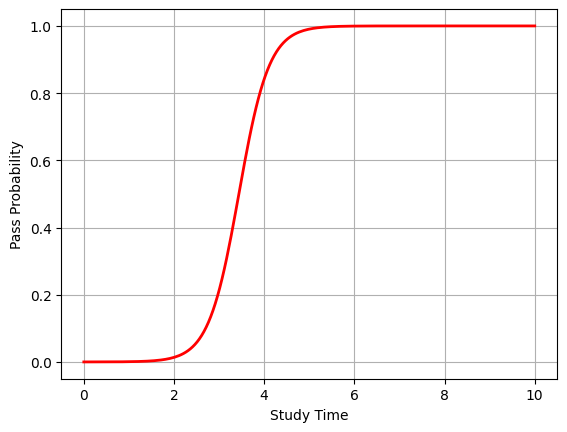

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 공부 시간 (X), 합격 여부 (y)
X = np.array([1,2,3,4,5,6,2,3,4,5,6,7,1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,10])
y = np.array([0,0,0,1,1,1,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,1,1])

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 하이퍼 파라미터 초기화
lr = 0.1  # 학습률
epochs = 5000

np.random.seed(42)  # 재현성 고정
a = np.random.randn()  # 기울기
b = np.random.randn()  # 절편

# Gradient Descent
for epoch in range(epochs):

    y_hat = sigmoid(a * X + b)

    # Loss (Cross Entropy)
    eps = 1e-10
    loss = -np.mean(y*np.log(y_hat+eps) + (1-y)*np.log(1-y_hat+eps))

    error = y_hat - y
    grad_a = np.mean(error * X)
    grad_b = np.mean(error)


    a -= lr * grad_a
    b -= lr * grad_b

    # Loss값 출력
    if epoch % 500 == 0:
      print(f"Epoch {epoch}, Loss={loss:.4f}, a={a:.4f}, b={b:.4f}")

# 학습 결과
print(a)
print(b)
print(loss)

# 시각화
X_test = np.linspace(0, 10, 200)
y_prob = sigmoid(a * X_test + b)

plt.plot(X_test, y_prob, color="red", linewidth=2)
plt.xlabel("Study Time")
plt.ylabel("Pass Probability")
plt.grid(True)
print()


#